# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [22]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np
from zavolab_pyutils.read_count_data_analysis import deseq2_normalize
from zavolab_pyutils.visualization import plot_size_factors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create sample count data

In [38]:
# Create sample count matrix (3000 genes x 4 samples)
N_genes = 20000
np.random.seed(42)
genes = [f"Gene_{i}" for i in range(1, N_genes+1)]
samples = ["Sample_1", "Sample_2", "Sample_3", "Sample_4"]
scaling_factors = [1, 2, 3, 4] # reflect true size factors

# Generate realistic count data (higher expression means higher counts)
counts_data = np.array()
for k,sample in enumerate(samples):
    counts_data_tmp = np.random.negative_binomial(50*scaling_factors[k], 0.3, size=(N_genes, 1)) + 50
    counts_data = counts_data + counts_data_tmp
counts_df = pd.DataFrame(counts_data, index=genes, columns=samples)

print("Input count matrix:")
print(counts_df.head())
print(f"\nShape: {counts_df.shape}")

TypeError: array() missing required argument 'object' (pos 0)

## Apply DESeq2-style normalization

In [35]:
# Apply normalization
norm_counts, sfs_df = deseq2_normalize(
    counts_df, 
    sample_list=samples,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts)
print(f"\nShape: {norm_counts.shape}")

Normalized count matrix:
              Sample_1    Sample_2    Sample_3    Sample_4
Gene_1      177.634110  168.152433  148.740742  173.621941
Gene_2      146.697833  161.146082  146.744222  161.648014
Gene_3      156.677277  191.173302  185.676362  121.734924
Gene_4      156.677277  155.140638  161.718122  166.637150
Gene_5      156.677277  156.141545  179.686802  199.565449
...                ...         ...         ...         ...
Gene_19996  151.687555  185.167858  154.730302  174.619768
Gene_19997  171.646444  173.156970  171.700722  208.545894
Gene_19998  186.615610  178.161507  154.730302  202.558931
Gene_19999  159.671110  184.166951  160.719862  200.563276
Gene_20000  133.724555  229.207781  129.773802  190.585004

[20000 rows x 4 columns]

Shape: (20000, 4)


## Size factors and QC metrics

In [36]:
print("Size factors and read metrics:")
print(sfs_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf   read_sum  read_sum_mln
sample                                               
Sample_1  1.002060  0.002969  3333671.0          3.33
Sample_2  0.999093 -0.001308  3328994.0          3.33
Sample_3  1.001743  0.002512  3334158.0          3.33
Sample_4  1.002177  0.003138  3337508.0          3.34


## Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [19]:
print(f"Median size factor: {sfs_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_df['sf'].mean():.3f}")
print("\n✓ Normalization completed successfully!")

Median size factor: 1.007
Mean size factor: 1.001

✓ Normalization completed successfully!


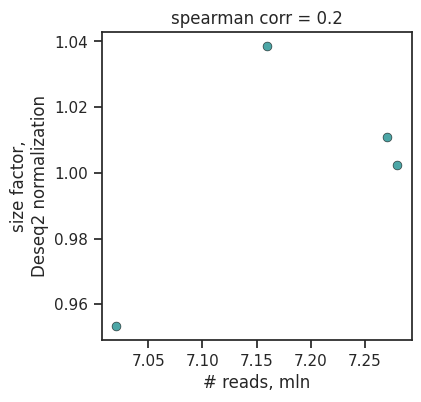

In [23]:
plot_size_factors(sfs_df,outdir='./tests/plots/')